In [2]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

ANNOTATION_DIR_MINMAX = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/annotations_minmax"
ANNOTATION_DIR_RAW = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/annotations"

GENOTYPE_DIR = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/genotypes"

GENES_LIST_FULL = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/genes_list_seed_random_full.txt"
GENES_LIST_LOG1P = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/genes_list_seed_random_log1p.txt"


In [3]:
# fix: ATAC chrombpnet
ANNOTATION_DIR_RAW_FIX = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/annotations_raw"
for chrom in range(1, 23):
    outdir = os.path.join(ANNOTATION_DIR_RAW_FIX, f"chr{chrom}")
    os.makedirs(outdir, exist_ok=True)
    print(f"Processing chromosome {chrom}...\n")
    # Load the annotations

    for annotation_file in os.listdir(os.path.join(ANNOTATION_DIR_RAW, f"chr{chrom}")):
        if annotation_file.endswith('.tsv.gz'):
            gene = annotation_file.split('_')[0]
            print(f"Processing {gene}")
            data = pd.read_csv(os.path.join(ANNOTATION_DIR_RAW, f"chr{chrom}", annotation_file), sep='\t')
            nvars_before = len(data)
            nanno_before = len(data.columns)
            
            for cell in ['microglia', 'astrocyte', 'neuron', 'oligodendrocyte']:
                print(f"\t...{cell}")
                chrombp = pd.read_csv(f"/gpfs/commons/groups/knowles_lab/data/ADSP_reguloML/ADSP_vcf/58K_preview_compact/rare_variants/chrombpnet/variant_peak_pairs_scored/zscore_normalized/rare_variant_chrombpnet_{cell}_ATAC_chr{chrom}_zscore.tsv.gz", 
                                        sep = "\t", usecols = ['CHR', 'BP', 'raw_score'])
                chrombp = chrombp.rename(columns={'CHR': 'chr', 'BP': 'pos'})
                chrombp = chrombp[chrombp['chr']==int(chrom)]
                chrombp = chrombp.drop(columns=['chr'])
                # make pos float
                chrombp['pos'] = chrombp['pos'].astype(float)
                chrombp['raw_score'] = pd.to_numeric(chrombp['raw_score'], errors='coerce').astype(float)
                data = data.merge(chrombp, on=['pos'], how='left')
                data[f'chrombpnet_log_counts_diff_{cell}'] = (
                    pd.to_numeric(data['raw_score'], errors='coerce').fillna(0.0).astype(float)
                )
                data = data.drop(columns=['raw_score'])
                # number of variants with zero log counts diff (before)
                nzero = len(data[data[f'log_counts_diff_chrombpnet_{cell}'] == 0])
                print(f"\t\t{nzero}")
                data = data.drop(columns=[f'log_counts_diff_chrombpnet_{cell}'])
                # number of variants with zero log counts diff (after)
                nnonzero = len(data[data[f'chrombpnet_log_counts_diff_{cell}'] == 0])
                print(f"\t\t{nnonzero}")
                
                assert len(data) == nvars_before
            
            nanno_after = len(data.columns)
            assert nanno_after == nanno_before
            data.set_index('variant_id', inplace=True)

            # save
            data.to_csv(os.path.join(outdir, f"{gene}_annotations.tsv.gz"), sep='\t', index=True)
            with open(os.path.join(outdir, f"{gene}_var_ids.txt"), "w") as f:
                var_ids = data.index.tolist()
                for var_id in var_ids:
                    f.write(f"{var_id}\n")
            tensor_out = os.path.join(outdir, f"{gene}_annotations.pt")
            bad_cols = data.dtypes[data.dtypes == 'object']
            if len(bad_cols) > 0:
                print(f"  !! object cols in {gene}: {bad_cols.to_dict()}")
                for c in bad_cols.index:
                    print(f"     sample of {c}: {data[c].dropna().unique()[:5]}")
                data = data.apply(pd.to_numeric, errors='coerce').fillna(0.0)
            torch.save(torch.tensor(data.values, dtype=torch.float32), tensor_out)

    




Processing chromosome 1...

Processing ENSG00000169905
	...microglia
		1070
		1076
	...astrocyte
		1075
		1092
	...neuron
		1070
		1081
	...oligodendrocyte
		1066
		1081
Processing ENSG00000058085
	...microglia
		1377
		1375
	...astrocyte
		1369
		1382
	...neuron
		1354
		1361
	...oligodendrocyte
		1381
		1379
Processing ENSG00000170382
	...microglia
		1440
		1441
	...astrocyte
		1415
		1437
	...neuron
		1385
		1415
	...oligodendrocyte
		1428
		1429
Processing ENSG00000158055
	...microglia
		1219
		1229
	...astrocyte
		1204
		1230
	...neuron
		1237
		1244
	...oligodendrocyte
		1221
		1234
Processing ENSG00000011021
	...microglia
		1168
		1187
	...astrocyte
		1158
		1176
	...neuron
		1133
		1204
	...oligodendrocyte
		1139
		1172
Processing ENSG00000163352
	...microglia
		625
		630
	...astrocyte
		596
		604
	...neuron
		615
		643
	...oligodendrocyte
		611
		627
Processing ENSG00000126070
	...microglia
		1044
		1061
	...astrocyte
		1036
		1066
	...neuron
		1016
		1076
	...oligodendrocyte


TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [19]:
data

,variant_id,chr,pos,MAP20,phyloP17way_primate,phyloP30way_mammalian,phastCons17way_primate_rankscore,phastCons30way_mammalian,GERP_RS,bStatistic,...,splice,ABC_microglia,ABC_neuron,ABC_oligodendrocyte,ABC_astrocyte,dist_to_TSS,chrombpnet_log_counts_diff_microglia,chrombpnet_log_counts_diff_astrocyte,chrombpnet_log_counts_diff_neuron,chrombpnet_log_counts_diff_oligodendrocyte
0,1:179740033_A_T,1.0,179740033.0,0.900,-0.415,0.431,0.14158,0.007,-0.352,764.0,...,0.0,0.0,0.0,0.0,0.0,5.139155,0.0,0.0,0.0,0.0
1,1:179740457_G_A,1.0,179740457.0,1.000,-0.487,0.009,0.18454,0.003,0.462,764.0,...,0.0,0.0,0.0,0.0,0.0,5.137816,0.0,0.0,0.0,0.0
2,1:179740573_C_G,1.0,179740573.0,1.000,-0.390,-0.048,0.77633,0.000,-2.040,764.0,...,0.0,0.0,0.0,0.0,0.0,5.137449,0.0,0.0,0.0,0.0
3,1:179740627_C_G,1.0,179740627.0,1.000,-0.649,-0.533,0.39275,0.004,-0.708,764.0,...,0.0,0.0,0.0,0.0,0.0,5.137278,0.0,0.0,0.0,0.0
4,1:179740695_G_A,1.0,179740695.0,0.950,0.498,0.003,0.71945,0.010,-0.249,764.0,...,0.0,0.0,0.0,0.0,0.0,5.137063,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,1:179976255_A_G,1.0,179976255.0,1.000,0.504,-0.125,0.82271,0.438,-2.830,203.0,...,0.0,0.0,0.0,0.0,0.0,4.993225,0.0,0.0,0.0,0.0
1119,1:179976886_G_T,1.0,179976886.0,0.975,-0.332,-0.212,0.64760,0.279,-0.960,203.0,...,0.0,0.0,0.0,0.0,0.0,4.995999,0.0,0.0,0.0,0.0
1120,1:179977141_G_T,1.0,179977141.0,1.000,-0.393,-0.344,0.24690,0.005,0.282,203.0,...,0.0,0.0,0.0,0.0,0.0,4.997115,0.0,0.0,0.0,0.0
1121,1:179977171_G_C,1.0,179977171.0,0.975,0.448,0.615,0.29219,0.008,0.563,203.0,...,0.0,0.0,0.0,0.0,0.0,4.997247,0.0,0.0,0.0,0.0


In [22]:
import load_data

genes = pd.read_csv(GENES_LIST_FULL, header=None).values.flatten()
Z_df_minmax, _, _, _ = load_data.load_annotations_only({'annotation_dir': ANNOTATION_DIR_MINMAX, 'genes': genes})
Z_df_raw, _, _, _ = load_data.load_annotations_only({'annotation_dir': ANNOTATION_DIR_RAW, 'genes': genes})


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:01<00:00, 114.25it/s]


Annotation-only matrix: 216146 variants × 28 features
Annotation matrix (only): 17 annotations per variant


100%|██████████| 200/200 [00:02<00:00, 88.67it/s]


Annotation-only matrix: 216146 variants × 58 features
Annotation matrix (only): 49 annotations per variant


In [23]:
Z_df_minmax.head()
Z_df_raw.head()

,chr,pos,MAP20,phyloP17way_primate,phyloP30way_mammalian,phastCons17way_primate_rankscore,phastCons30way_mammalian,GERP_RS,bStatistic,integrated_fitCons_score,...,alphamissense,splice,ABC_microglia,ABC_neuron,ABC_oligodendrocyte,ABC_astrocyte,dist_to_TSS,chrombpnet,TF_delta_min,TF_delta_max
ENSG00000167536_17:28798428,17.0,28798428.0,0.900,-0.449,-0.403,0.24690,0.008,-3.63000,124.0,0.084033,...,0.0,0.0,0.0,0.0,0.0,0.0,5.019743,0.0,0.0,0.0
ENSG00000167536_17:28798449,17.0,28798449.0,1.000,-0.467,-0.203,0.08282,0.001,-4.52000,124.0,0.106106,...,0.0,0.0,0.0,0.0,0.0,0.0,5.019656,0.0,0.0,0.0
ENSG00000167536_17:28798592,17.0,28798592.0,1.000,-0.392,-0.347,0.96559,0.413,-0.00603,124.0,0.107560,...,0.0,0.0,0.0,0.0,0.0,0.0,5.019062,0.0,0.0,0.0
ENSG00000167536_17:28799383,17.0,28799383.0,0.000,-1.022,-0.808,0.27109,0.005,0.14000,124.0,0.099367,...,0.0,0.0,0.0,0.0,0.0,0.0,5.015762,0.0,0.0,0.0
ENSG00000167536_17:28799733,17.0,28799733.0,0.375,-0.756,-0.696,0.18454,0.003,0.15800,124.0,0.088506,...,0.0,0.0,0.0,0.0,0.0,0.0,5.014294,0.0,0.0,0.0


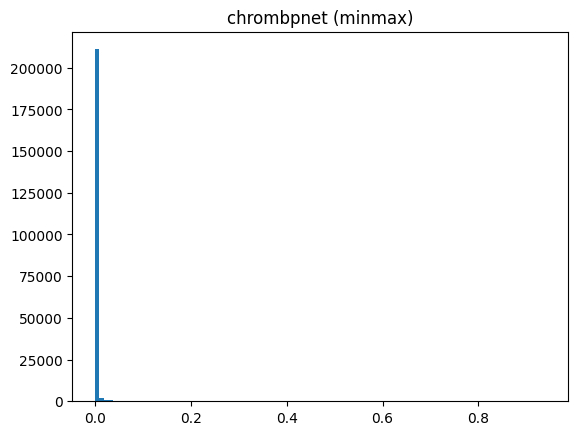

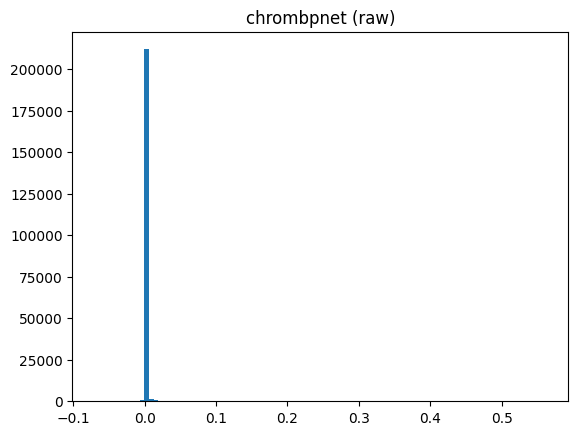

In [24]:
# plot distributino of annotation values

def plot_annotation_distribution(Z_df, annotation_name, scaling : str = 'minmax'):
    if scaling == 'minmax':
        plt.hist(Z_df[annotation_name], bins=100)
        plt.title(f'{annotation_name} (minmax)')
    elif scaling == 'raw':
        plt.hist(Z_df_raw[annotation_name], bins=100)
        plt.title(f'{annotation_name} (raw)')
    plt.show()

plot_annotation_distribution(Z_df_minmax, 'chrombpnet')
plot_annotation_distribution(Z_df_raw, 'chrombpnet', 'raw')



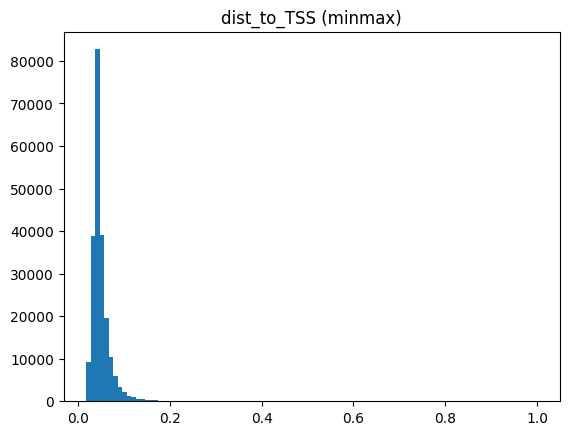

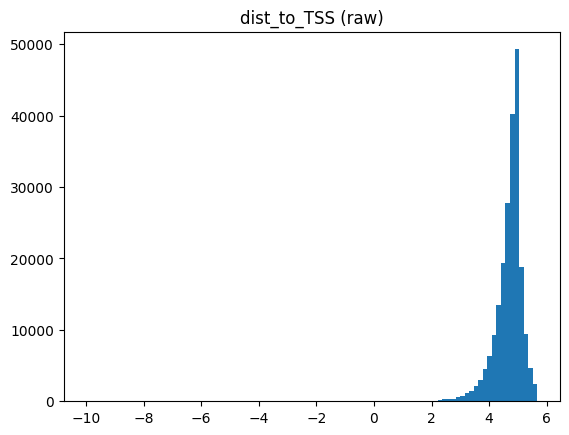

In [25]:
plot_annotation_distribution(Z_df_minmax, 'dist_to_TSS')
plot_annotation_distribution(Z_df_raw, 'dist_to_TSS', 'raw')


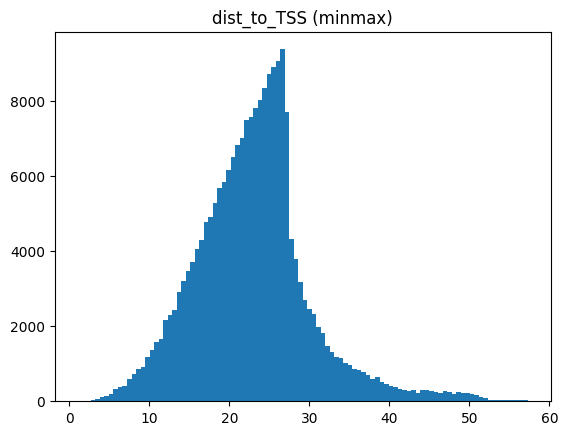

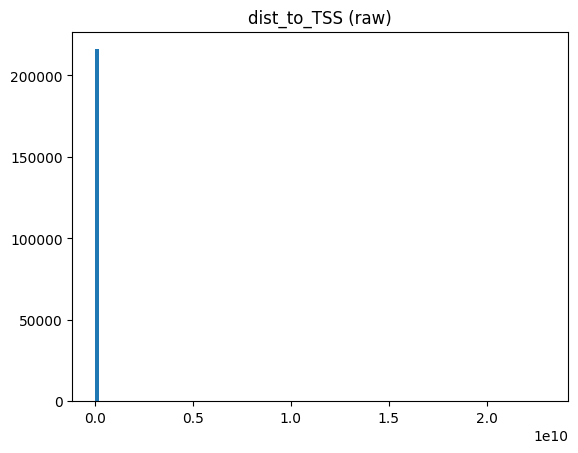

In [26]:
Z_df_minmax['dist_to_TSS'] = 1/Z_df_minmax['dist_to_TSS']
Z_df_raw['dist_to_TSS'] = 1/Z_df_raw['dist_to_TSS']

plot_annotation_distribution(Z_df_minmax, 'dist_to_TSS')
plot_annotation_distribution(Z_df_raw, 'dist_to_TSS', 'raw')

